<a href="https://colab.research.google.com/github/sleacee/pet-projects-pandas/blob/main/Food%20Composition%20Data%20USDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

#загрузка данных
data = pd.read_excel('ABBREV_with_CLASS.xlsx')

#проведение статистического анализа для количественных признаков
quantitative_stats = data.describe()
print("Статистические показатели для количественных признаков:")
print(quantitative_stats)

#проведение статистического анализа для категориальных признаков
categorical_stats = data.describe(include=['object'])
print("\nСтатистические показатели для категориальных признаков:")
print(categorical_stats)

Статистические показатели для количественных признаков:
        Unnamed: 0        NDB_No    Water_(g)   Energ_Kcal  Protein_(g)  \
count  8790.000000   8790.000000  8789.000000  8790.000000  8790.000000   
mean   4394.500000  15663.495222    54.112218   226.317634    11.342849   
std    2537.598767   9251.413586    30.772854   169.877539    10.530474   
min       0.000000   1001.000000     0.000000     0.000000     0.000000   
25%    2197.250000   9086.250000    29.700000    91.000000     2.380000   
50%    4394.500000  14427.500000    63.080000   191.000000     8.000000   
75%    6591.750000  20142.750000    77.960000   337.000000    19.880000   
max    8789.000000  93600.000000   100.000000   902.000000    88.320000   

       Lipid_Tot_(g)      Ash_(g)  Carbohydrt_(g)  Fiber_TD_(g)  \
count    8790.000000  8465.000000     8790.000000   8196.000000   
mean       10.553725     1.783468       22.127710      2.187445   
std        15.814842     3.004609       27.270822      4.383138   



Количество пропущенных значений по столбцам:
Unnamed: 0              0
NDB_No                  0
Shrt_Desc               0
Water_(g)               1
Energ_Kcal              0
Protein_(g)             0
Lipid_Tot_(g)           0
Ash_(g)               325
Carbohydrt_(g)          0
Fiber_TD_(g)          594
Sugar_Tot_(g)        1832
Calcium_(mg)          348
Iron_(mg)             144
Magnesium_(mg)        739
Phosphorus_(mg)       579
Potassium_(mg)        426
Sodium_(mg)            83
Zinc_(mg)             706
Copper_mg)           1257
Manganese_(mg)       2160
Selenium_(µg)        1700
Vit_C_(mg)            818
Thiamin_(mg)          634
Riboflavin_(mg)       616
Niacin_(mg)           637
Panto_Acid_mg)       2242
Vit_B6_(mg)           905
Folate_Tot_(µg)      1261
Folic_Acid_(µg)      2039
Food_Folate_(µg)     1768
Folate_DFE_(µg)      2057
Choline_Tot_ (mg)    4016
Vit_B12_(µg)         1193
Vit_A_IU              711
Vit_A_RAE            1535
Retinol_(µg)         1806
Alpha_Carot_(µg)  

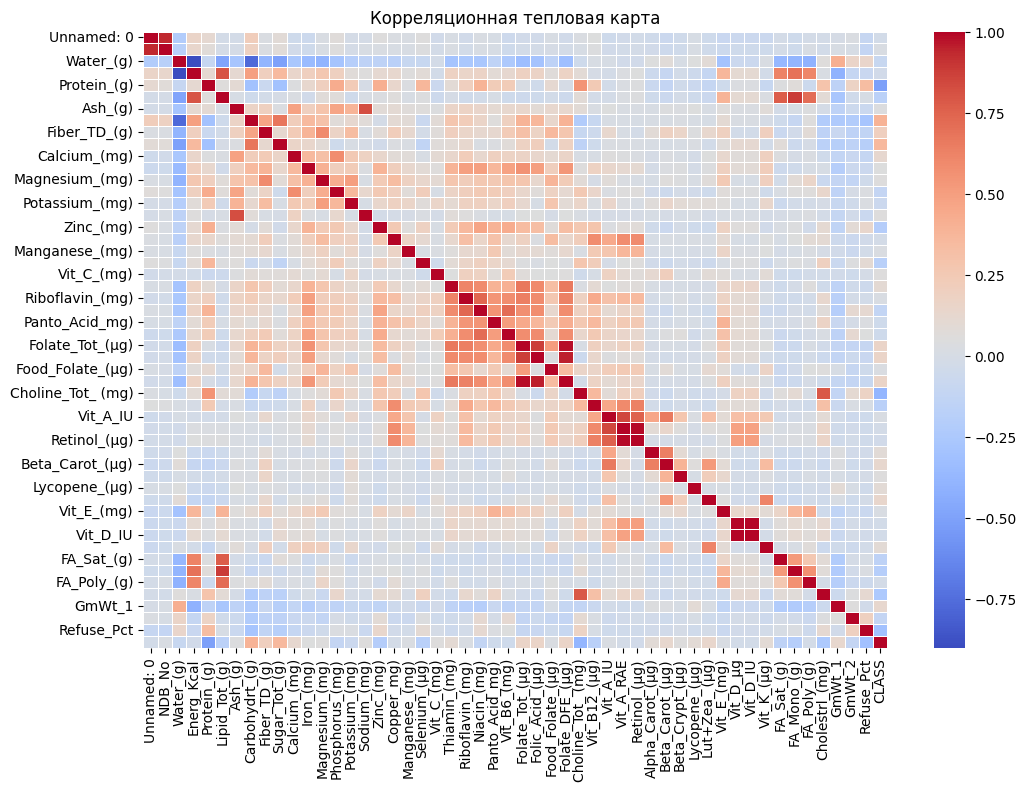


Распределение классов:
CLASS
0     3428
10    3362
11    1462
1      538
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#проверка наличия пропущенных значений
print("\nКоличество пропущенных значений по столбцам:")
print(data.isnull().sum())

#выбор числовых столбцов
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

#создание корреляционной матрицы
correlation_matrix = data[numerical_columns].corr()

#построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная тепловая карта')
plt.show()

#анализ классов
class_distribution = data['CLASS'].value_counts()
print("\nРаспределение классов:")
print(class_distribution)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

#замена пропущенных значений в категориальных признаках на наиболее часто встречающееся значение
categorical_columns = ['Shrt_Desc', 'GmWt_Desc1', 'GmWt_Desc2']
for column in categorical_columns:
    most_frequent_value = data[column].mode()[0]
    data[column].fillna(most_frequent_value, inplace=True)

numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_columns] = data[numerical_columns].fillna(data[numerical_columns].median())

#отделение столбца с меткой CLASS
X = data.drop(columns=['CLASS'])
y = data['CLASS']

#преобразование категориальных признаков методом Ordinal Encoding
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X[categorical_columns])
X_encoded_df = pd.DataFrame(X_encoded, columns=categorical_columns)
X.drop(columns=categorical_columns, inplace=True)
X = pd.concat([X, X_encoded_df], axis=1)


#разделение данных на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#масштабирование признаков (необходимо для KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(data[data['NDB_No'] == 10130]) #нет sugar_tot
print("\nПример обработанных данных:")
print(X_train.head())

      Unnamed: 0  NDB_No  Shrt_Desc  Water_(g)  Energ_Kcal  Protein_(g)  \
2598        2598   10130       2336      72.34         110        20.31   

      Lipid_Tot_(g)  Ash_(g)  Carbohydrt_(g)  Fiber_TD_(g)  ...  FA_Sat_(g)  \
2598           2.62     3.38            1.34           0.0  ...         0.9   

      FA_Mono_(g)  FA_Poly_(g)  Cholestrl_(mg)  GmWt_1  GmWt_Desc1  GmWt_2  \
2598         1.09        0.467            48.0    85.0         826    57.0   

      GmWt_Desc2  Refuse_Pct  CLASS  
2598         866         0.0     10  

[1 rows x 55 columns]

Пример обработанных данных:
      Unnamed: 0  NDB_No  Water_(g)  Energ_Kcal  Protein_(g)  Lipid_Tot_(g)  \
2598        2598   10130      72.34         110        20.31           2.62   
3202        3202   11503      92.47          19         2.60           0.20   
6206        6206   19182      62.94         225         4.14          16.00   
2485        2485   10007      26.26         626         7.06          66.10   
694       

Точность:  0.850967007963595


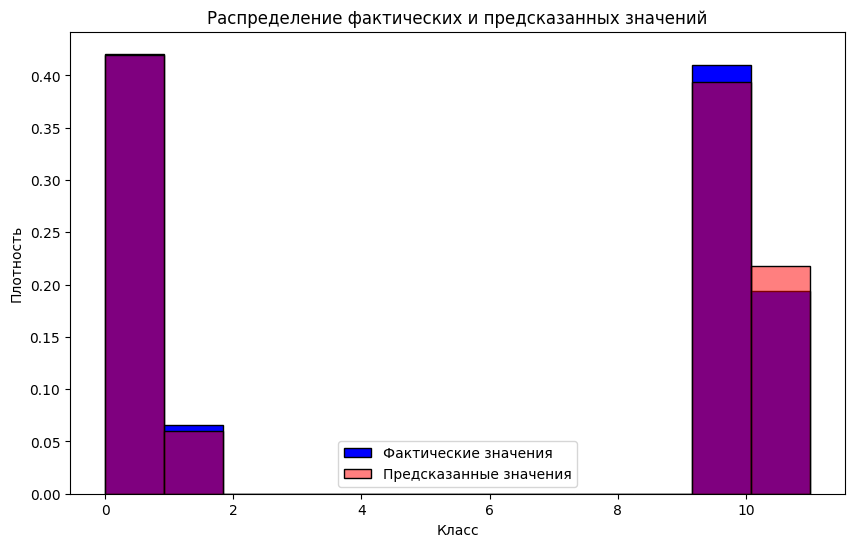

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#инициализация и обучение классификатора KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

#предсказание на тестовом наборе
y_pred = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred)

print('Точность: ', accuracy_knn)
#создание фигуры
plt.figure(figsize=(10, 6))

sns.histplot(y_test, color='blue', label='Фактические значения', stat='density', alpha=1)
sns.histplot(y_pred, color='red', label='Предсказанные значения', stat='density', alpha=0.5)
plt.xlabel('Класс')
plt.ylabel('Плотность')
plt.title('Распределение фактических и предсказанных значений')
plt.legend()

#отображение графика
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#создание экземпляров нормализаторов
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

#применение нормализации к данным
X_train_scaled_standard = scaler_standard.fit_transform(X_train)

X_train_scaled_minmax = scaler_minmax.fit_transform(X_train)

#вывод результата
print("Пример первых значений нормализованных данных с использованием StandardScaler:")
print(X_train_scaled_standard)

print("\nПример первых значений нормализованных данных с использованием MinMaxScaler:")
print(X_train_scaled_minmax)

Пример первых значений нормализованных данных с использованием StandardScaler:
[[-0.71236499 -0.60395917  0.60295559 ... -0.80881936  1.28361146
   2.31447039]
 [-0.47378447 -0.45412212  1.25660408 ...  1.43269906 -0.94897092
   1.42647962]
 [ 0.71279807  0.38389592  0.29772479 ... -0.26665704 -0.02203445
  -1.5487472 ]
 ...
 [ 0.39047738  0.17774719  0.34967897 ...  0.24025878  1.28361146
   0.82685698]
 [-1.39887646 -1.15965495  0.29934836 ... -0.50625398  0.80391283
  -1.56247901]
 [ 1.13307897  0.82020222 -0.08608669 ... -1.26821183  1.28361146
   1.00994786]]

Пример первых значений нормализованных данных с использованием MinMaxScaler:
[[0.29558388 0.1020139  0.7234     ... 0.2659078  0.90869087 0.94130435]
 [0.36432962 0.11735846 0.9247     ... 0.91018782 0.22772277 0.73043478]
 [0.7062372  0.20317843 0.6294     ... 0.42174161 0.51045105 0.02391304]
 ...
 [0.61336217 0.1820671  0.6454     ... 0.56744451 0.90869087 0.58804348]
 [0.09776918 0.04510606 0.6299     ... 0.35287422 0.76

In [ ]:
#инициализация моделей
knn_standard = KNeighborsClassifier()
knn_minmax = KNeighborsClassifier()

#обучение моделей на нормализованных данных
knn_standard.fit(X_train_scaled_standard, y_train)
knn_minmax.fit(X_train_scaled_minmax, y_train)

#предсказание на тестовом наборе данных
y_pred_knn_standard = knn_standard.predict(X_test_scaled_standard)
y_pred_knn_minmax = knn_minmax.predict(X_test_scaled_minmax)

#оценка производительности моделей
accuracy_knn_standard = accuracy_score(y_test, y_pred_knn_standard)
accuracy_knn_minmax = accuracy_score(y_test, y_pred_knn_minmax)

#вывод результатов
print("Точность моделей без нормализации:")
print("- KNeighborsClassifier:", accuracy_knn)
print()

print("Точность моделей с использованием StandardScaler:")
print("- KNeighborsClassifier:", accuracy_knn_standard)
print()

print("Точность моделей с использованием MinMaxScaler:")
print("- KNeighborsClassifier:", accuracy_knn_minmax)

Точность моделей без нормализации:
- KNeighborsClassifier: 0.8532423208191127

Точность моделей с использованием StandardScaler:
- KNeighborsClassifier: 0.8532423208191127

Точность моделей с использованием MinMaxScaler:
- KNeighborsClassifier: 0.8373151308304891


In [ ]:
from sklearn.model_selection import GridSearchCV

#зададим сетку параметров для поиска
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  #количество соседей
    'metric': ['euclidean', 'manhattan']  #метрики расстояния
}

#инициализируем модель KNeighborsClassifier
knn = KNeighborsClassifier()

#создаем экземпляр GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

#обучаем GridSearch на тренировочных данных
grid_search.fit(X_train_scaled_standard, y_train)

#выводим наилучшие параметры
print("Наилучшие параметры:", grid_search.best_params_)

#получаем наилучшую модель
best_knn = grid_search.best_estimator_

#предсказываем на тестовом наборе
y_pred_best = best_knn.predict(X_test_scaled_standard)

#оценка производительности модели
accuracy_best = accuracy_score(y_test, y_pred_best)
print("Точность наилучшей модели:", accuracy_best)

Наилучшие параметры: {'metric': 'manhattan', 'n_neighbors': 5}
Точность наилучшей модели: 0.8873720136518771


In [ ]:
from sklearn.preprocessing import LabelEncoder

#кодирование категориальных признаков
label_encoder = LabelEncoder()
data['Shrt_Desc'] = label_encoder.fit_transform(data['Shrt_Desc'])
data['GmWt_Desc1'] = label_encoder.fit_transform(data['GmWt_Desc1'])
data['GmWt_Desc2'] = label_encoder.fit_transform(data['GmWt_Desc2'])

#оставляем только один из сильно коррелирующих признаков
data_filtered = data.drop(['Riboflavin_(mg)'], axis=1)

#разделение данных на признаки и метки классов
X_filtered = data_filtered.drop('CLASS', axis=1)
y_filtered = data_filtered['CLASS']

#разделение на тренировочный и тестовый наборы
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

#нормализация данных (если требуется)

#обучение модели KNeighborsClassifier на отфильтрованных данных
knn_filtered = KNeighborsClassifier()
knn_filtered.fit(X_train_filtered, y_train_filtered)

#предсказание на тестовом наборе
y_pred_filtered = knn_filtered.predict(X_test_filtered)

#оценка производительности модели
accuracy_filtered = accuracy_score(y_test_filtered, y_pred_filtered)
print("Точность модели с одним из сильно коррелирующих признаков:", accuracy_filtered)

Точность модели с одним из сильно коррелирующих признаков: 0.7872582480091013


In [ ]:
#создание нового признака "Среднее значение витамина A" путем объединения связанных признаков
data['Vitamin_A'] = data[['Vit_A_IU', 'Vit_A_RAE', 'Retinol_(µg)', 'Alpha_Carot_(µg)', 'Beta_Carot_(µg)', 'Beta_Crypt_(µg)']].mean(axis=1)

#удаление исходных связанных признаков
data = data.drop(['Vit_A_IU', 'Vit_A_RAE', 'Retinol_(µg)', 'Alpha_Carot_(µg)', 'Beta_Carot_(µg)', 'Beta_Crypt_(µg)'], axis=1)
#кодирование категориальных признаков
label_encoder = LabelEncoder()

#разделение данных на признаки и метки классов
X_vitamin_a = data.drop('CLASS', axis=1)
y_vitamin_a = data['CLASS']

#разделение на тренировочный и тестовый наборы
X_train_vitamin_a, X_test_vitamin_a, y_train_vitamin_a, y_test_vitamin_a = train_test_split(X_vitamin_a, y_vitamin_a, test_size=0.2, random_state=42)

#нормализация данных (если требуется)

#обучение модели KNeighborsClassifier на отфильтрованных данных
knn_vitamin_a = KNeighborsClassifier()
knn_vitamin_a.fit(X_train_vitamin_a, y_train_vitamin_a)

#предсказание на тестовом наборе
y_pred_vitamin_a = knn_vitamin_a.predict(X_test_vitamin_a)

#оценка производительности модели
accuracy_vitamin_a = accuracy_score(y_test_vitamin_a, y_pred_vitamin_a)
print("Точность модели с объединенной группой признаков для витамина A:", accuracy_vitamin_a)

Точность модели с объединенной группой признаков для витамина A: 0.7872582480091013


In [ ]:
import random

best_accuracy_random = 0
best_features_random = None

for _ in range(100):
    #выбор случайного поднабора признаков
    selected_features = random.sample(list(X_train.columns), k=5)  #выбираем 5 случайных признаков

    #выбор данных только с выбранными признаками
    X_train_random = X_train[selected_features]
    X_test_random = X_test[selected_features]

    #обучение модели KNeighborsClassifier
    knn_random = KNeighborsClassifier()
    knn_random.fit(X_train_random, y_train)

    #предсказание на тестовом наборе
    y_pred_random = knn_random.predict(X_test_random)

    #оценка производительности модели
    accuracy_random = accuracy_score(y_test, y_pred_random)

    #сохранение лучших результатов
    if accuracy_random > best_accuracy_random:
        best_accuracy_random = accuracy_random
        best_features_random = selected_features

print("Лучший результат:", best_accuracy_random)
print("Лучшие признаки:", best_features_random)

Лучший результат: 0.8475540386803185
Лучшие признаки: ['Vit_D_µg', 'Carbohydrt_(g)', 'Lut+Zea_ (µg)', 'Refuse_Pct', 'Sugar_Tot_(g)']


In [ ]:
from sklearn.decomposition import PCA

#создание экземпляра PCA с заданным числом компонент
pca = PCA(n_components=5)  #выбираем 5 главных компонент

#применение PCA к данным
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

#обучение модели KNeighborsClassifier на данных с уменьшенной размерностью
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)

#предсказание на тестовом наборе
y_pred_pca = knn_pca.predict(X_test_pca)

#оценка производительности модели
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("Точность модели с использованием PCA для уменьшения размерности данных:", accuracy_pca)

Точность модели с использованием PCA для уменьшения размерности данных: 0.7713310580204779


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

#отбор 10 наиболее информативных признаков
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

#масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

#обучение модели KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

#предсказание на тестовом наборе
y_pred = knn.predict(X_test_scaled)

#оценка производительности модели
accuracy = accuracy_score(y_test, y_pred)
print("Точность модели после отбора и подготовки признаков:", accuracy)

Точность модели после отбора и подготовки признаков: 0.8492605233219568
